In [4]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# FICHIER STOPS

In [7]:
INPUT_PATH = "./data/stops.txt"
EXPORT_PATH = "./exports/stops_with_geom.csv"

In [5]:
def process_stops(input_path, output_path):
    df = pd.read_csv(input_path)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df.stop_lon, df.stop_lat),
        crs="EPSG:4326"
    )
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    gdf.to_csv(output_path, index=False)
    print(f"Exported {len(gdf)} stops to {output_path}")


In [13]:
df = pd.read_csv("./data/stops.txt")

print("Colonnes:")
print(df.columns.tolist())



Colonnes:
['stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon', 'zone_id', 'location_type', 'parent_station', 'stop_timezone', 'wheelchair_boarding']


In [14]:
print("\nTypes des donnees:")
print(df.dtypes)


Types des donnees:
stop_id                 object
stop_code               object
stop_name               object
stop_lat               float64
stop_lon               float64
zone_id                 object
location_type            int64
parent_station          object
stop_timezone           object
wheelchair_boarding      int64
dtype: object


In [17]:
print("premier lignes:")
print(df.head())

premier lignes:
  stop_id stop_code                          stop_name   stop_lat  stop_lon  \
0       1    ABBAT8                          Abattoirs  43.717886  7.284703   
1       2    ABBAT4                          Abattoirs  43.718399  7.284448   
2       3    ROSEL2                 Abbaye de Roseland  43.693389  7.228426   
3       4    ROSEL8                 Abbaye de Roseland  43.693219  7.228365   
4       5     ARSE4  Abbaye de Roseland / Napoléon III  43.688851  7.231361   

  zone_id  location_type parent_station stop_timezone  wheelchair_boarding  
0     NaN              0   place_101376           NaN                    1  
1     NaN              0   place_101376           NaN                    1  
2     NaN              0   place_096609           NaN                    0  
3     NaN              0   place_096609           NaN                    0  
4     NaN              0   place_096610           NaN                    0  


In [18]:
print("\n valeurs nulles:")
print(df.isna().sum())


 valeurs nulles:
stop_id                   0
stop_code              1651
stop_name                 0
stop_lat                  0
stop_lon                  0
zone_id                4481
location_type             0
parent_station         1672
stop_timezone          2813
wheelchair_boarding       0
dtype: int64


In [19]:
process_stops(INPUT_PATH, EXPORT_PATH)


Exported 4485 stops to ./exports/stops_with_geom.csv


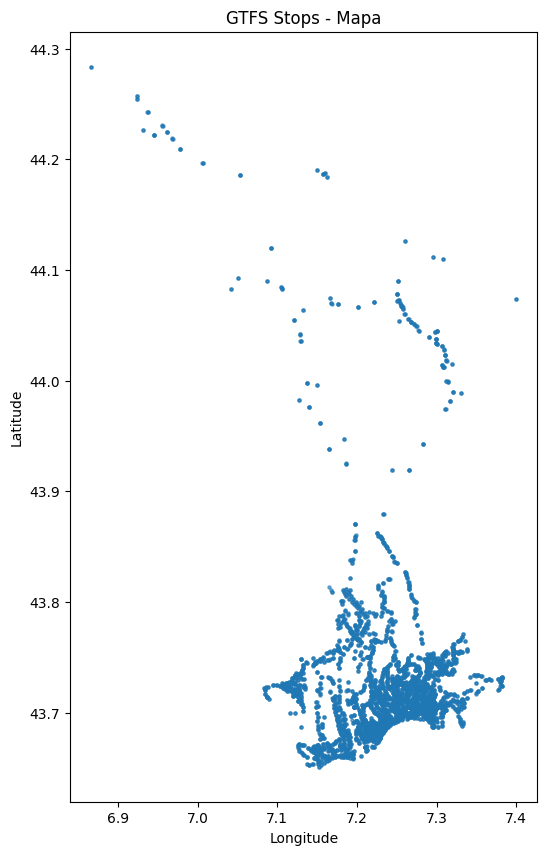

In [20]:
df = pd.read_csv(EXPORT_PATH)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.stop_lon, df.stop_lat),
    crs="EPSG:4326"
)

gdf.plot(figsize=(10, 10), markersize=5, alpha=0.6)
plt.title("GTFS Stops - Mapa")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

